# Imports

In [1]:
import dataset_loader as dl
import datasets_from_loader_utils as dflu
from some_functions import *

import numpy as np

import matplotlib.pyplot as plt

import tensorflow as tf
layers = tf.keras.layers

import cv2
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [2]:
dl.IMAGE_SIZE = 128
dl.BATCH_SIZE = 32

In [3]:
coco_train = dl.coco_RGB_dataset_precomputed(
    split='train',
    channels=1,
    tfrecord_path='tfrecords\\image_mask_train.tfrecord'
    # tfrecord_path='tfrecords\\train_32.tfrecord'
)

coco_val = dl.coco_RGB_dataset_precomputed(
    split='val',
    channels=1,
    tfrecord_path='tfrecords\\image_mask_val.tfrecord'
    # tfrecord_path='tfrecords\\val_32.tfrecord'
)

train images batch shape: (32, 128, 128, 1)
train masks  batch shape: (32, 128, 128)


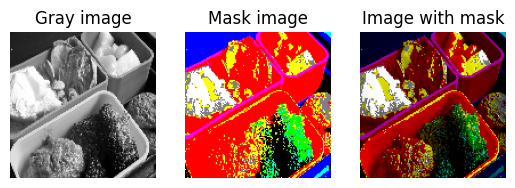

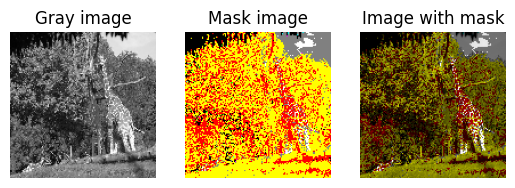

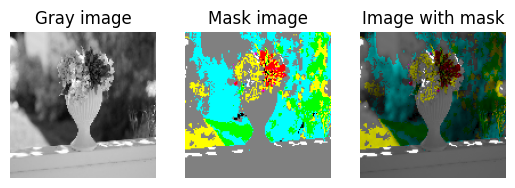

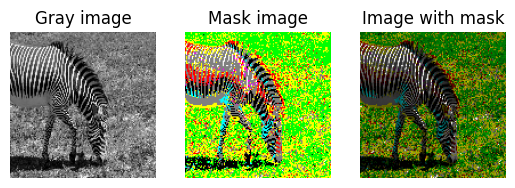

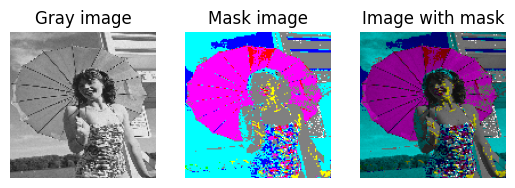

In [4]:
for images, masks in coco_train.take(1):
    print("train images batch shape:", images.shape)
    print("train masks  batch shape:", masks.shape)
    images_with_mask = dflu.apply_mask_to_image(images, masks)
    for index in range(dl.BATCH_SIZE):
        image_with_mask = images_with_mask[index]
        plt.subplot(1, 3, 1)
        plt.title("Gray image")
        plt.imshow(images[index], cmap="gray")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.title("Mask image")
        plt.imshow(dflu.coco_rgb_colors[masks[index]])
        plt.axis("off")
        
        plt.subplot(1, 3, 3)
        plt.title("Image with mask")
        plt.imshow(image_with_mask)
        plt.axis("off")
        
        plt.show()
        if index == 4:
            break

In [5]:
# coco_train = dl.coco_RGB_dataset_precomputed(
#     split='train',
#     channels=1,
#     tfrecord_path='tfrecords\\train_32.tfrecord'
# )

# coco_val = dl.coco_RGB_dataset_precomputed(
#     split='val',
#     channels=1,
#     tfrecord_path='tfrecords\\val_32.tfrecord'
# )

# Check masks

In [ ]:
dflu.first_batch_masks(coco_train)

# Pre Model

In [6]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [7]:
train_steps, val_steps = dl.coco_cardinality()

for _, masks in coco_train.take(1):
    print("min/max mask IDs:", tf.reduce_min(masks), tf.reduce_max(masks))

for _, masks in coco_val.take(1):
    print("min/max mask IDs:", tf.reduce_min(masks), tf.reduce_max(masks))

loading annotations into memory...
Done (t=11.41s)
creating index...
index created!
loading annotations into memory...
Done (t=0.99s)
creating index...
index created!
min/max mask IDs: tf.Tensor(0, shape=(), dtype=int32) tf.Tensor(8, shape=(), dtype=int32)
min/max mask IDs: tf.Tensor(0, shape=(), dtype=int32) tf.Tensor(8, shape=(), dtype=int32)


# Model

In [ ]:
# model = tf.keras.models.Sequential()
# model.add(layers.Input(shape=input_shape))
# model.add(layers.MaxPooling2D((2)))
# model.add(layers.Conv2D(dl.IMAGE_SIZE // (4 * BAD_MODEL_COEFFICIENT), (dl.IMAGE_SIZE // 2) * 2 + 1,
#                     activation='relu', padding='same'))
# model.add(MaxPooling2D((2)))
# model.add(BatchNormalization())
# model.add(Conv2D(dataset_loader.IMAGE_SIZE // (2 * BAD_MODEL_COEFFICIENT), (dataset_loader.IMAGE_SIZE // 4) * 2 + 1,
#                     activation='relu', padding='same'))
# model.add(Conv2D(dataset_loader.IMAGE_SIZE // (2 * BAD_MODEL_COEFFICIENT), (dataset_loader.IMAGE_SIZE // 4) * 2 + 1,
#                     activation='relu', padding='same'))
# model.add(MaxPooling2D((2)))
# model.add(BatchNormalization())
# model.add(Conv2D(dataset_loader.IMAGE_SIZE // BAD_MODEL_COEFFICIENT, (dataset_loader.IMAGE_SIZE // 8) * 2 + 1,
#                     activation='relu', padding='same'))
# model.add(Conv2D(dataset_loader.IMAGE_SIZE // BAD_MODEL_COEFFICIENT, (dataset_loader.IMAGE_SIZE // 8) * 2 + 1,
#                     activation='relu', padding='same'))

# model.add(UpSampling2D((2)))
# model.add(BatchNormalization())
# model.add(Conv2D(dataset_loader.IMAGE_SIZE // (2 * BAD_MODEL_COEFFICIENT), (dataset_loader.IMAGE_SIZE // 4) * 2 + 1,
#                     activation='relu', padding='same'))
# model.add(Conv2D(dataset_loader.IMAGE_SIZE // (2 * BAD_MODEL_COEFFICIENT), (dataset_loader.IMAGE_SIZE // 4) * 2 + 1,
#                     activation='relu', padding='same'))
# model.add(UpSampling2D((2)))
# model.add(BatchNormalization())
# model.add(Conv2D(dataset_loader.IMAGE_SIZE // (4 * BAD_MODEL_COEFFICIENT), (dataset_loader.IMAGE_SIZE // 2) * 2 + 1,
#                     activation='relu', padding='same'))
# model.add(UpSampling2D((2)))
# model.add(Conv2D(dataset_loader.COCO_NUM_CLASSES, 1, activation='softmax'))


# model = Sequential()
# model.add(Input(shape=input_shape))
# model.add(MaxPooling2D((2)))
# model.add(Conv2D(dataset_loader.IMAGE_SIZE // (4 * BAD_MODEL_COEFFICIENT), (dataset_loader.IMAGE_SIZE // 2) * 2 + 1,
#                     activation='relu', padding='same'))
# model.add(MaxPooling2D((2)))
# model.add(BatchNormalization())
# model.add(Conv2D(dataset_loader.IMAGE_SIZE // (2 * BAD_MODEL_COEFFICIENT), (dataset_loader.IMAGE_SIZE // 4) * 2 + 1,
#                     activation='relu', padding='same'))
# model.add(Conv2D(dataset_loader.IMAGE_SIZE // (2 * BAD_MODEL_COEFFICIENT), (dataset_loader.IMAGE_SIZE // 4) * 2 + 1,
#                     activation='relu', padding='same'))
# model.add(MaxPooling2D((2)))
# model.add(BatchNormalization())
# model.add(Conv2D(dataset_loader.IMAGE_SIZE // BAD_MODEL_COEFFICIENT, (dataset_loader.IMAGE_SIZE // 8) * 2 + 1,
#                     activation='relu', padding='same'))
# model.add(Conv2D(dataset_loader.IMAGE_SIZE // BAD_MODEL_COEFFICIENT, (dataset_loader.IMAGE_SIZE // 8) * 2 + 1,
#                     activation='relu', padding='same'))

# model.add(UpSampling2D((2)))
# model.add(BatchNormalization())
# model.add(Conv2D(dataset_loader.IMAGE_SIZE // (2 * BAD_MODEL_COEFFICIENT), (dataset_loader.IMAGE_SIZE // 4) * 2 + 1,
#                     activation='relu', padding='same'))
# model.add(Conv2D(dataset_loader.IMAGE_SIZE // (2 * BAD_MODEL_COEFFICIENT), (dataset_loader.IMAGE_SIZE // 4) * 2 + 1,
#                     activation='relu', padding='same'))
# model.add(UpSampling2D((2)))
# model.add(BatchNormalization())
# model.add(Conv2D(dataset_loader.IMAGE_SIZE // (4 * BAD_MODEL_COEFFICIENT), (dataset_loader.IMAGE_SIZE // 2) * 2 + 1,
#                     activation='relu', padding='same'))
# model.add(UpSampling2D((2)))
# model.add(Conv2D(dataset_loader.COCO_NUM_CLASSES, 1, activation='softmax'))

# model = tf.keras.models.Sequential(
#     [
#         Input(shape=input_shape),

#         Conv2D(128, (3, 3), activation='relu', padding='same'),
#         BatchNormalization(),
#         MaxPooling2D(4, 4),

#         Conv2D(256, (3, 3), activation='relu', padding='same'),
#         BatchNormalization(),
#         MaxPooling2D(4, 4),

#         Conv2D(512, (3, 3), activation='relu', padding='same'),
#         BatchNormalization(),
#         MaxPooling2D(4, 4),

#         Dropout(0.3),

#         UpSampling2D(4),
#         Conv2DTranspose(512, (3, 3), activation='relu', padding='same'),
#         BatchNormalization(),

#         UpSampling2D(4),
#         Conv2DTranspose(256, (3, 3), activation='relu', padding='same'),
#         BatchNormalization(),

#         UpSampling2D(4),
#         Conv2DTranspose(128, (3, 3), activation='relu', padding='same'),
#         BatchNormalization(),

#         Conv2D(dataset_loader.COCO_NUM_CLASSES, 1, activation='softmax')
#     ]
# )

model = tf.keras.models.Sequential(
    [
        layers.Input(shape=(dl.IMAGE_SIZE, dl.IMAGE_SIZE, 1)),
        # layers.Lambda(lambda x: tf.expand_dims(x, axis=-1)),

        layers.Conv2D(128, (5, 5), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(4, 4),

        # layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(256, (5, 5), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(4, 4),

        # layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        # layers.BatchNormalization(),
        # layers.MaxPooling2D(4, 4),

        layers.Dropout(0.3),

        # layers.UpSampling2D(4),
        # layers.Conv2DTranspose(512, (3, 3), activation='relu', padding='same'),
        # layers.BatchNormalization(),

        layers.UpSampling2D(4),
        # layers.Conv2DTranspose(256, (3, 3), activation='relu', padding='same'),
        layers.Conv2DTranspose(128, (5, 5), activation='relu', padding='same'),
        layers.BatchNormalization(),

        layers.UpSampling2D(4),
        # layers.Conv2DTranspose(128, (5, 5), activation='relu', padding='same'),
        # layers.BatchNormalization(),

        # layers.Conv2D(dl.COCO_NUM_CLASSES, 1, activation='softmax')
        layers.Conv2D(3, 1, activation='softmax')
    ]
)

model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="mean_squared_error",
    metrics=["mae"]
)


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 128, 128, 128)     1280      
                                                                 
 batch_normalization_10 (Bat  (None, 128, 128, 128)    512       
 chNormalization)                                                
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 32, 32, 128)      0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 32, 32, 256)       295168    
                                                                 
 batch_normalization_11 (Bat  (None, 32, 32, 256)      1024      
 chNormalization)                                                
                                                      

In [7]:
for images, masks in coco_train.take(1):
    print("train images batch shape:", images.shape)
    print("train masks  batch shape:", masks.shape)

train images batch shape: (32, 128, 128, 1)
train masks  batch shape: (32, 128, 128)


In [12]:
early_stop = tf.keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True,
)
model.fit(
    coco_train,
    epochs=2,
    steps_per_epoch=train_steps,
    validation_data=coco_val,
    validation_steps=val_steps,
    callbacks=[early_stop]
)

NameError: name 'train_steps' is not defined

# LOAD MODEL FROM AGENT 1

In [20]:
# msh_model = tf.keras.models.load_model("models/precompv3_60.keras", custom_objects={'dice_loss': dice_loss, 'combined_loss': combined_loss, "SegmentationMeanIoU": SegmentationMeanIoU})
# msh_model = tf.keras.models.load_model("models/st32_40.keras", custom_objects={'dice_loss': dice_loss, 'combined_loss': combined_loss, "SegmentationMeanIoU": SegmentationMeanIoU})
MODEL_PATH = "models/max128_12.keras"
msh_model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        'weighted_combined_loss': weighted_combined_loss,
        'WeightedMeanIoU': WeightedMeanIoU(num_classes=dl.COCO_NUM_CLASSES)
    }
)

In [7]:
# y_true_list = []
# for _, masks in coco_val.take(val_steps):
#     flat = tf.reshape(masks, [-1]).numpy()  # shape (batch*H*W,)
#     y_true_list.append(flat)


# y_pred_list = []
# for batch_preds in msh_model.predict(coco_val.take(val_steps)):
#     preds_flat = np.argmax(batch_preds, axis=-1).reshape(-1)  # (batch*H*W,)
#     y_pred_list.append(preds_flat)

# y_true = np.concatenate(y_true_list)
# y_pred = np.concatenate(y_pred_list)

# num_classes = len(dflu.coco_rgb_labels)  # 9
# y_pred = np.clip(y_pred, 0, num_classes - 1)
# y_true = np.clip(y_true, 0, num_classes - 1)

# cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))  # Include all labels 0–8

# # Use all label names
# used_label_names = dflu.coco_rgb_labels  # All 9 labels

# cm_log = np.log1p(cm)

# # Plot
# fig, ax = plt.subplots(figsize=(10, 10))
# disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=used_label_names)
# disp.plot(include_values=False, xticks_rotation=90, cmap='Blues', ax=ax)
# plt.title("Confusion Matrix")
# plt.grid(False)
# plt.tight_layout()
# plt.show()


1/1 [==============================] - 0s 188ms/step


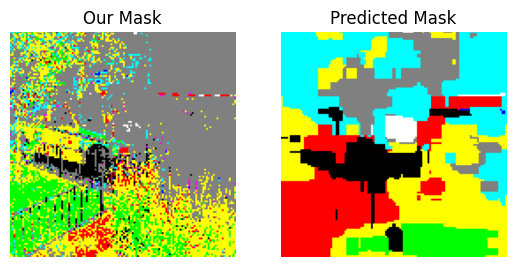

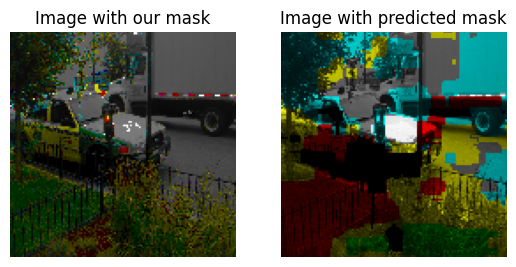

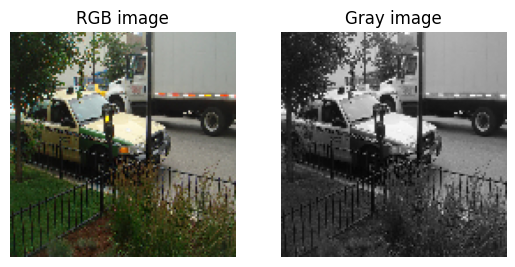

1/1 [==============================] - 0s 83ms/step


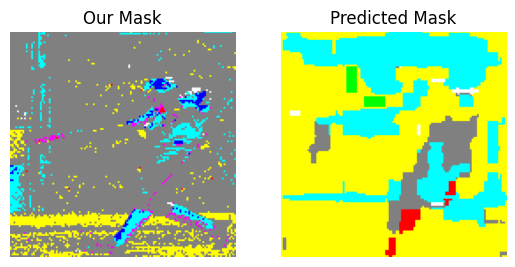

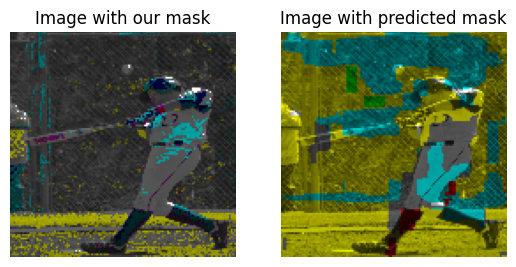

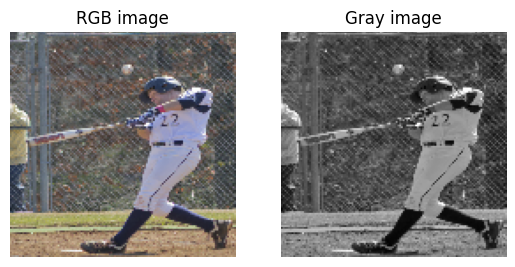

1/1 [==============================] - 0s 88ms/step


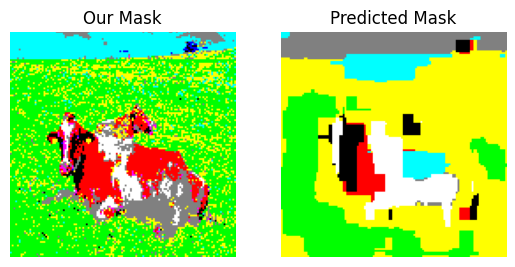

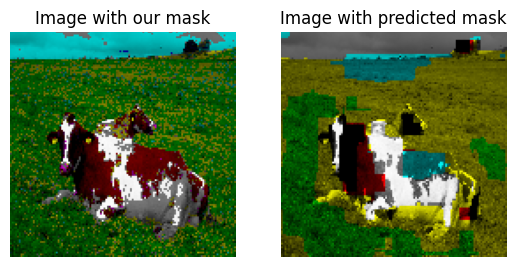

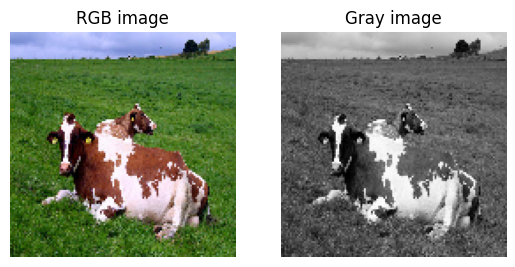

1/1 [==============================] - 0s 93ms/step


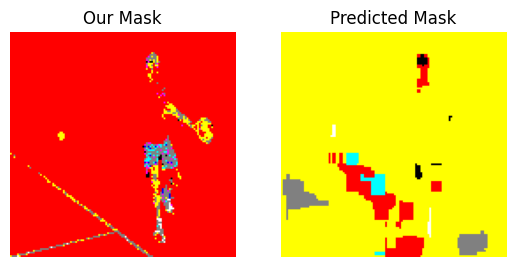

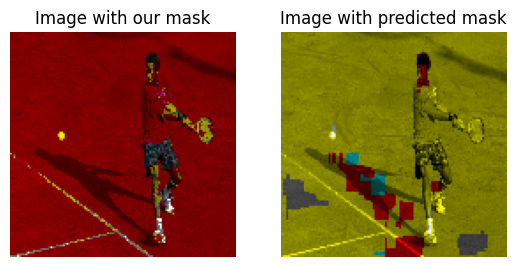

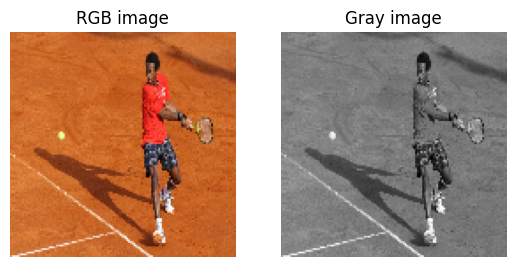

1/1 [==============================] - 0s 91ms/step


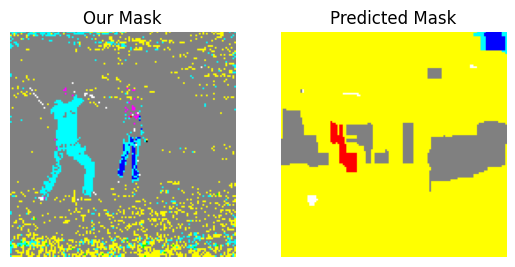

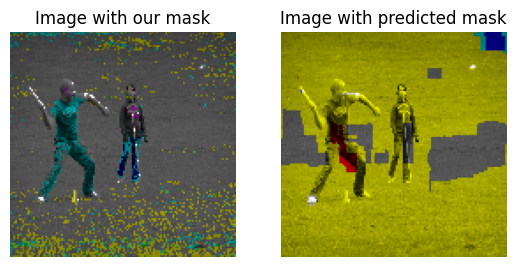

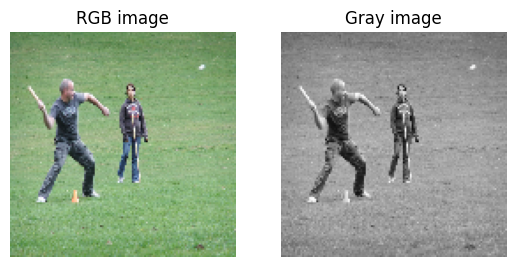

1/1 [==============================] - 0s 78ms/step


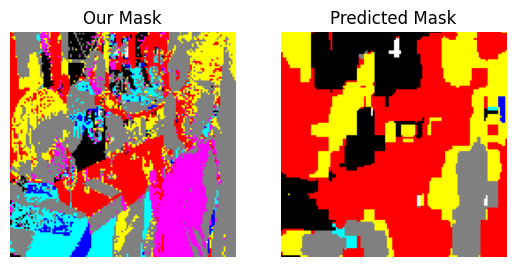

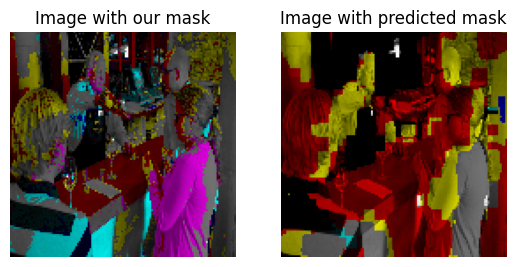

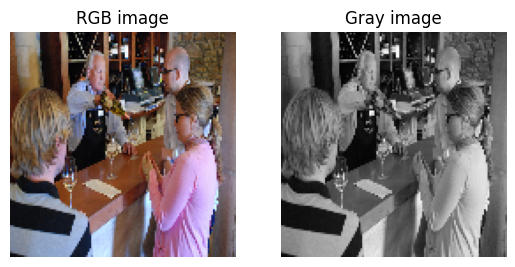

1/1 [==============================] - 0s 97ms/step


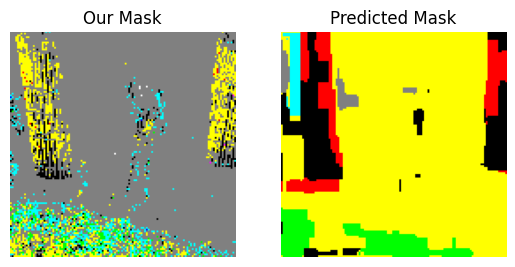

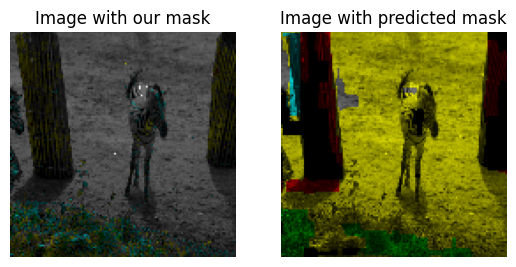

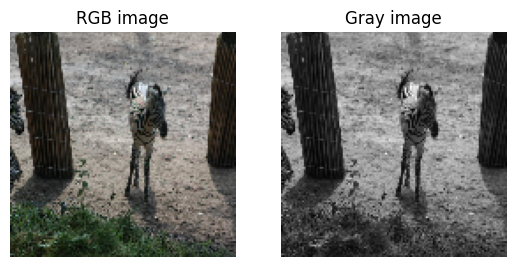

1/1 [==============================] - 0s 84ms/step


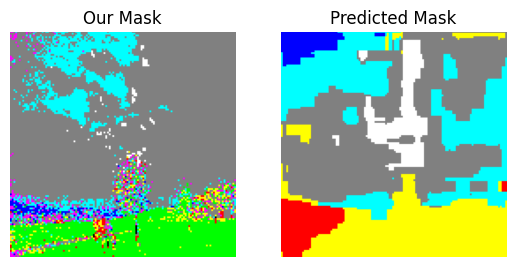

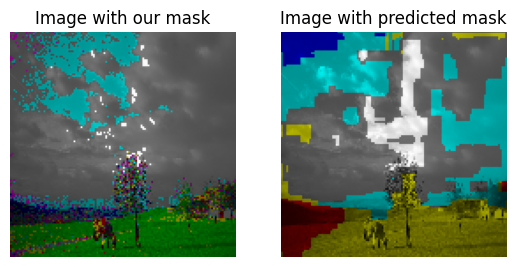

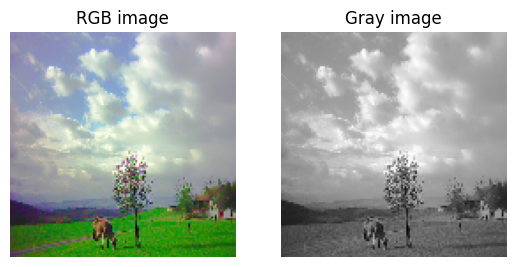

1/1 [==============================] - 0s 92ms/step


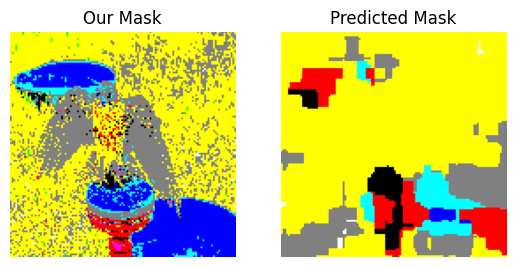

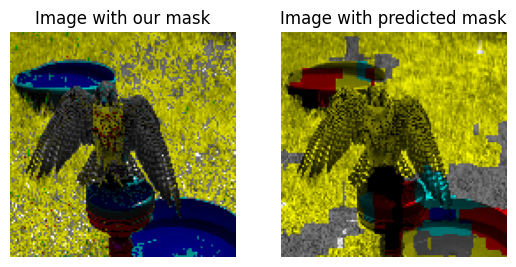

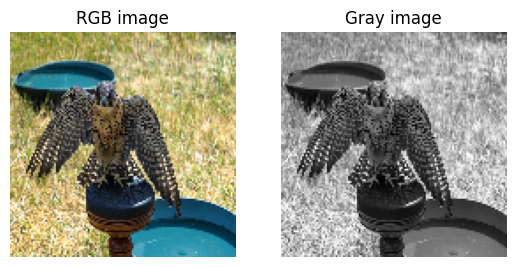

1/1 [==============================] - 0s 86ms/step


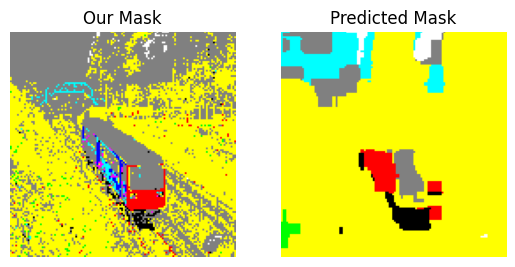

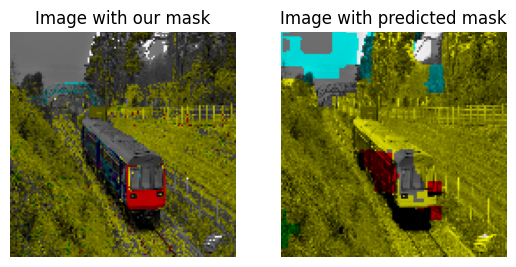

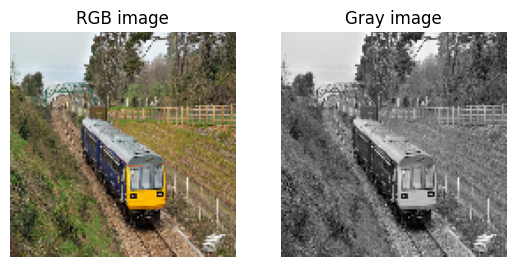

1/1 [==============================] - 0s 79ms/step


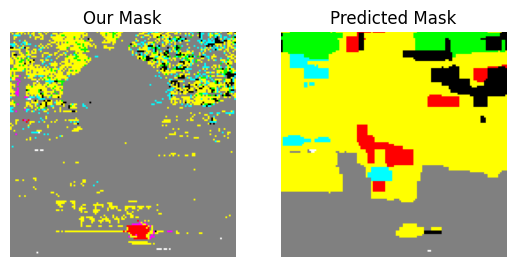

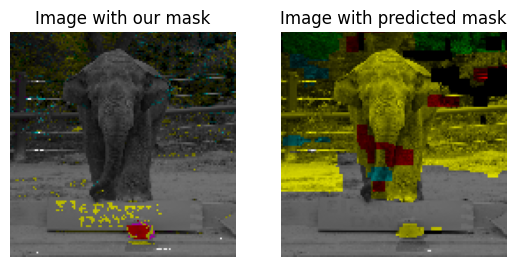

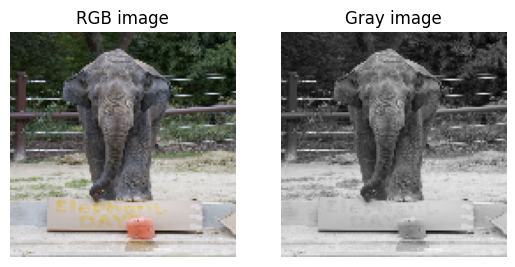

1/1 [==============================] - 0s 84ms/step


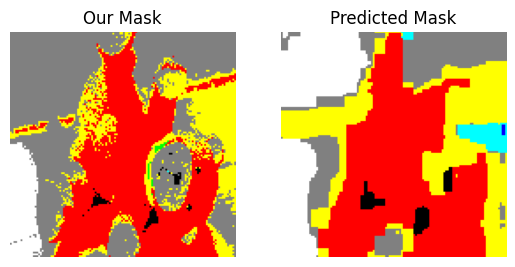

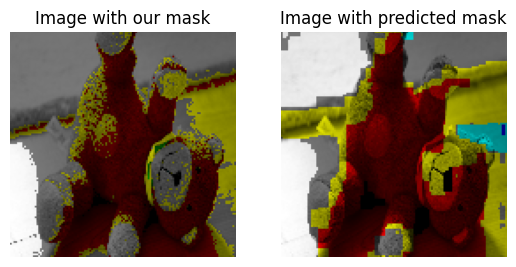

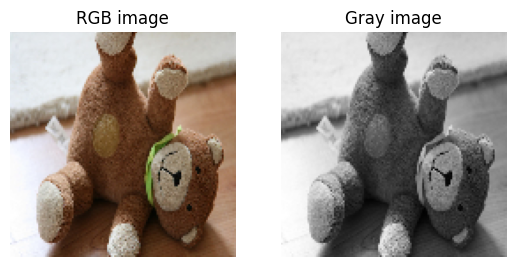

1/1 [==============================] - 0s 81ms/step


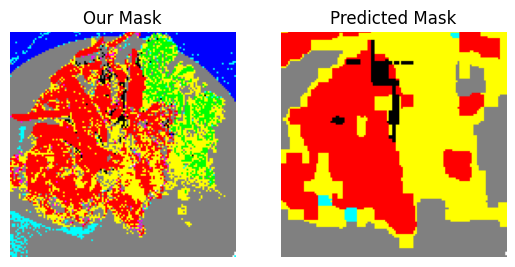

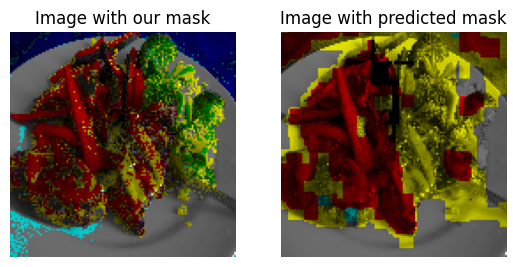

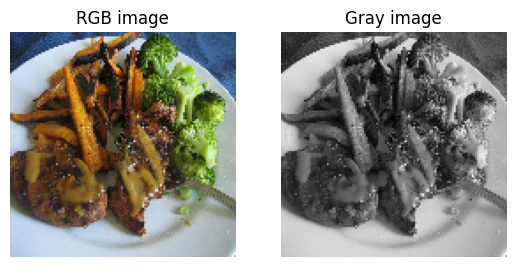

1/1 [==============================] - 0s 81ms/step


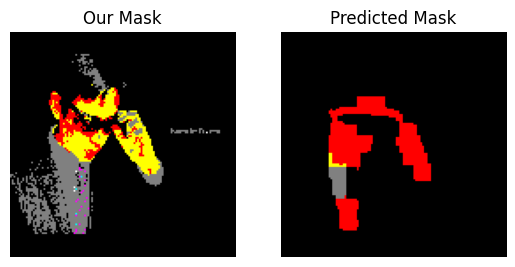

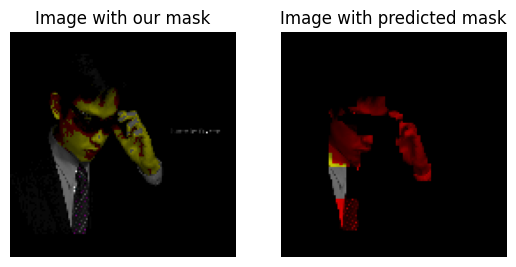

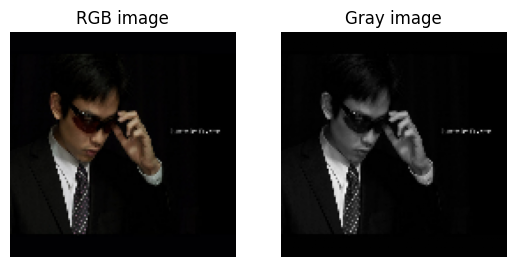

1/1 [==============================] - 0s 82ms/step


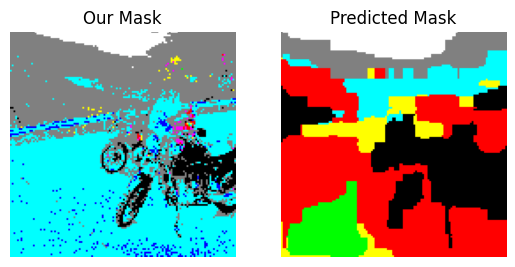

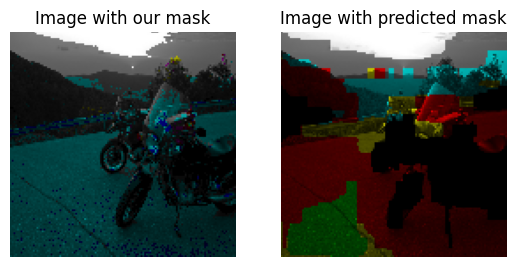

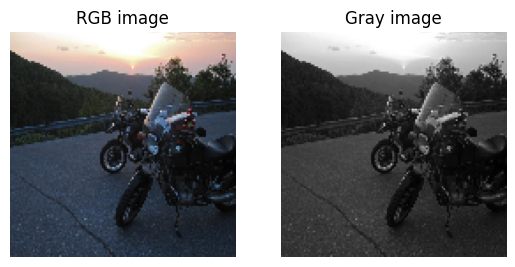

1/1 [==============================] - 0s 93ms/step


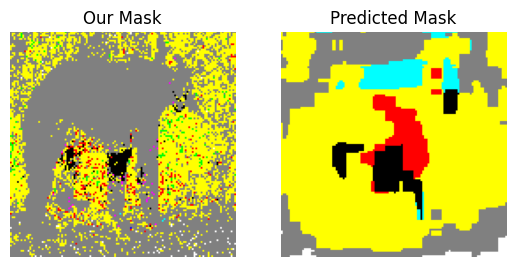

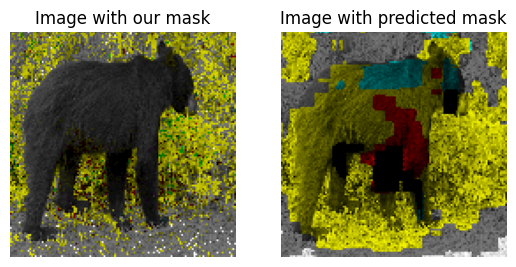

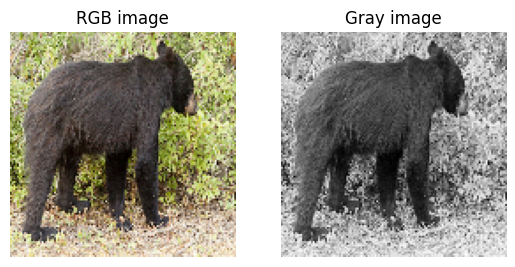

In [21]:
file_name = "datasets\\untitl34ed.png"
file_name = "datasets\\lemon.jpg"
file_name = "datasets\\melon.jpg"
file_name = "datasets\\plane.jpg"
count = 0
for file_name in os.listdir("datasets/test2017"):
    try:
        # print(file_name)
        # file_name = "datasets\\kode-lgx-dr-ghostx.jpg"
        # file_name = "datasets\\NewYearSkelet.jpg"

        # for images, mask in coco_train.take(1):
        #     print("train images batch shape:", images.shape)
        #     print("train masks  batch shape:", mask.shape)

        image_ = cv2.imread("datasets\\test2017\\" + file_name, cv2.IMREAD_COLOR_RGB)
        # print(image_)
        # plt.imshow(image_)
        # plt.show()
        image_ = cv2.resize(image_, (dl.IMAGE_SIZE, dl.IMAGE_SIZE))

        image = cv2.imread("datasets\\test2017\\" + file_name, cv2.IMREAD_GRAYSCALE)

        image = cv2.resize(image, (dl.IMAGE_SIZE, dl.IMAGE_SIZE))
    except Exception as e:
        print(e)
        continue
    plt.subplot(1, 2, 1)
    plt.title("Our Mask")
    random_mask = dl.rgb_to_label_map(image_)
    plt.imshow(dflu.coco_rgb_colors[random_mask])
    plt.axis("off")

    image = np.expand_dims(image, axis=0)/255

    mask_pred = msh_model.predict(image)
    mask_pred = tf.argmax(mask_pred, axis=3)
    # mask = mask.astype(bool)
    # index_mask = np.argmax(mask, axis=-1)

    plt.subplot(1, 2, 2)
    plt.title("Predicted Mask")
    # plt.imshow(index_mask[0], cmap="gray")
    plt.imshow(dflu.coco_rgb_colors[mask_pred[0]], cmap="gray")
    plt.axis("off")
    plt.show()

    # rgb_image = dflu.apply_mask_to_image(image, index_mask)
    rgb_image = dflu.apply_mask_to_image(image, mask_pred)

    # random_mask = np.random.randint(0, dl.COCO_NUM_CLASSES, (1, dl.IMAGE_SIZE, dl.IMAGE_SIZE))

    rgb_random_image = dflu.apply_mask_to_image(image, random_mask)

    plt.subplot(1, 2, 2)
    plt.title("Image with predicted mask")
    plt.imshow(rgb_image[0])
    plt.axis("off")

    plt.subplot(1, 2, 1)
    plt.title("Image with our mask")
    plt.imshow(rgb_random_image[0])
    plt.axis("off")

    plt.show()

    plt.subplot(1, 2, 1)
    plt.title("RGB image")
    plt.imshow(image_)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Gray image")
    plt.imshow(image[0], cmap="gray")
    plt.axis("off")

    plt.show()
    count += 1
    if count == 16:
        break

    # diff = np.abs(image_ - rgb_image[0])  # shape: (128, 128, 3)

    # diff_norm = np.linalg.norm(image_ - rgb_image[0], axis=-1)  # shape: (128, 128)
    # diff_vis = (diff_norm / np.max(diff_norm)) if np.max(diff_norm) > 0 else diff_norm

    # plt.imshow(diff_vis, cmap='hot')
    # plt.title("Per-Pixel RGB Distance")
    # plt.colorbar(label='Distance (0–1 normalized)')
    # plt.axis('off')
    # plt.show()

In [9]:
image_.reshape(-1), rgb_image[0].shape

(array([151, 162, 121, ..., 222, 205, 188], dtype=uint8), (128, 128, 3))

In [10]:
raise Exception

Exception: 

# Thrash

In [ ]:
def rgb_to_label(mask_rgb, color_map):
    """
    Convert RGB mask to class indices using coco_rgb_colors.
    mask_rgb: np.array shape (H, W, 3)
    color_map: np.array shape (9, 3)
    """
    label_mask = np.zeros(mask_rgb.shape[:2], dtype=np.uint8)
    for i, color in enumerate(color_map):
        matches = np.all(mask_rgb == color, axis=-1)
        label_mask[matches] = i
    return label_mask


In [ ]:
def preprocess_gray_image(gray_img):
    gray_img = gray_img.astype(np.float32) / 255.0  # normalize
    return np.expand_dims(gray_img, axis=-1)        # (H, W) → (H, W, 1)


In [ ]:
from tensorflow.keras import layers, models

def build_unet(input_shape=(None, None, 1), num_classes=9):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(8, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(16, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)

    # Decoder
    x = layers.Conv2DTranspose(16, 3, strides=2, activation='relu', padding='same')(x)
    x = layers.Conv2DTranspose(8, 3, strides=2, activation='relu', padding='same')(x)

    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(x)

    return models.Model(inputs, outputs)


In [ ]:
model = build_unet(input_shape=(dl.IMAGE_SIZE, dl.IMAGE_SIZE, 1), num_classes=9)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [ ]:
model.summary()

In [ ]:
history = model.fit(
    train,
    batch_size=dl.BATCH_SIZE,
    epochs=2,
    steps_per_epoch=train_steps,
    validation_data=val,
    validation_steps=val_steps
)

In [ ]:
pred = model.predict(val)  # shape (1, H, W, 9)
pred_class = np.argmax(pred[0], axis=-1)          # shape (H, W)

# Convert label map back to RGB
pred_rgb = dflu.coco_rgb_colors[pred_class]
